In [3]:
import pandas as pd
import os
print(os.getcwd())

C:\Users\tofaj


In [4]:
df = pd.read_csv("C:/Users/tofaj/Downloads/db.csv", encoding = 'windows-1254') #import dataset
df.head() 

,Unnamed: 0,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide
0,1,Iron Man,Marvel,7.9,79,126,2008,140000000,98618668,318604126,585366247
1,2,The Incredible Hulk,Marvel,6.7,61,112,2008,150000000,55414050,134806913,263427551
2,3,Iron Man 2,Marvel,7.0,57,124,2010,200000000,128122480,312433331,623933331
3,4,Thor,Marvel,7.0,57,115,2011,150000000,65723338,181030624,449326618
4,5,Captain America: The First Avenger,Marvel,6.9,66,124,2011,140000000,65058524,176654505,370569774


In [5]:
df = df.drop('Unnamed: 0', axis=1) #drop Unnamed: 0 column
df.head()

,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide
0,Iron Man,Marvel,7.9,79,126,2008,140000000,98618668,318604126,585366247
1,The Incredible Hulk,Marvel,6.7,61,112,2008,150000000,55414050,134806913,263427551
2,Iron Man 2,Marvel,7.0,57,124,2010,200000000,128122480,312433331,623933331
3,Thor,Marvel,7.0,57,115,2011,150000000,65723338,181030624,449326618
4,Captain America: The First Avenger,Marvel,6.9,66,124,2011,140000000,65058524,176654505,370569774


In [6]:
#check for missing values
print(df.isnull().sum())

Original Title         0
Company                0
Rate                   0
Metascore              0
Minutes                0
Release                0
Budget                 0
Opening Weekend USA    0
Gross USA              0
Gross Worldwide        0
dtype: int64


In [7]:
df.info() #check info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Original Title       39 non-null     object 
 1   Company              39 non-null     object 
 2   Rate                 39 non-null     float64
 3   Metascore            39 non-null     int64  
 4   Minutes              39 non-null     object 
 5   Release              39 non-null     int64  
 6   Budget               39 non-null     object 
 7   Opening Weekend USA  39 non-null     int64  
 8   Gross USA            39 non-null     int64  
 9   Gross Worldwide      39 non-null     int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 3.2+ KB


In [8]:
df.dtypes #check dtypes specifically

Original Title          object
Company                 object
Rate                   float64
Metascore                int64
Minutes                 object
Release                  int64
Budget                  object
Opening Weekend USA      int64
Gross USA                int64
Gross Worldwide          int64
dtype: object

In [9]:
df.columns

Index(['Original Title', 'Company', 'Rate', 'Metascore', 'Minutes', 'Release',
       'Budget', 'Opening Weekend USA', 'Gross USA', 'Gross Worldwide'],
      dtype='object')

In [10]:
df.describe()

,Rate,Metascore,Release,Opening Weekend USA,Gross USA,Gross Worldwide
count,39.000000,39.000000,39.000000,3.900000e+01,3.900000e+01,3.900000e+01
mean,7.202564,63.666667,2013.794872,1.151098e+08,3.232659e+08,8.275727e+08
std,1.074706,13.860837,4.286942,6.866708e+07,1.807086e+08,5.332318e+08
min,3.300000,27.000000,2004.000000,5.379365e+06,1.054712e+07,1.090331e+07
25%,6.900000,56.500000,2011.000000,6.539093e+07,2.032217e+08,4.843193e+08
50%,7.300000,67.000000,2015.000000,9.620234e+07,3.186041e+08,7.468469e+08
75%,7.850000,72.500000,2017.000000,1.559225e+08,4.085492e+08,1.104658e+09
max,9.000000,88.000000,2019.000000,3.571150e+08,8.583730e+08,2.797801e+09


In [11]:
#Data Cleaning

df.columns = df.columns.str.strip() #strip any whitespace from column names
df['Gross Worldwide'] = pd.to_numeric(df['Gross Worldwide'], errors = 'coerce') #covert column to numeric
df['Budget'] = pd.to_numeric(df['Budget'], errors = 'coerce') #convert col to numeric
df['Release Date'] = pd.to_datetime(df['Release'], errors = 'coerce') #convert col to datetime
df['Opening Weekend USA'] = pd.to_numeric(df['Opening Weekend USA'], errors = 'coerce') #convert to numeric
df['Minutes'] = pd.to_numeric(df['Minutes'], errors='coerce') #covert col to numeric
df.dropna(inplace=True) #drop rows with missing values
df.head()

,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide,Release Date
0,Iron Man,Marvel,7.9,79,126.0,2008,140000000.0,98618668,318604126,585366247,1970-01-01 00:00:00.000002008
4,Captain America: The First Avenger,Marvel,6.9,66,124.0,2011,140000000.0,65058524,176654505,370569774,1970-01-01 00:00:00.000002011
5,The Avengers,Marvel,8.0,69,143.0,2012,220000000.0,207438708,623357910,1518812988,1970-01-01 00:00:00.000002012
7,Thor: The Dark World,Marvel,6.9,54,112.0,2013,170000000.0,85737841,206362140,644783140,1970-01-01 00:00:00.000002013
8,Captain America: The Winter Soldier,Marvel,7.7,70,136.0,2014,170000000.0,95023721,259766572,714421503,1970-01-01 00:00:00.000002014


In [12]:
marvel = df[df['Company'] == "Marvel"] #get all marvel movies
marvel.head()

,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide,Release Date
0,Iron Man,Marvel,7.9,79,126.0,2008,140000000.0,98618668,318604126,585366247,1970-01-01 00:00:00.000002008
4,Captain America: The First Avenger,Marvel,6.9,66,124.0,2011,140000000.0,65058524,176654505,370569774,1970-01-01 00:00:00.000002011
5,The Avengers,Marvel,8.0,69,143.0,2012,220000000.0,207438708,623357910,1518812988,1970-01-01 00:00:00.000002012
7,Thor: The Dark World,Marvel,6.9,54,112.0,2013,170000000.0,85737841,206362140,644783140,1970-01-01 00:00:00.000002013
8,Captain America: The Winter Soldier,Marvel,7.7,70,136.0,2014,170000000.0,95023721,259766572,714421503,1970-01-01 00:00:00.000002014


In [13]:
DC = df[df['Company'] == 'DC']
DC.head()

,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide,Release Date
23,Catwoman,DC,3.3,27,104.0,2004,100000000.0,16728411,40202379,82102379,1970-01-01 00:00:00.000002004
24,Batman Begins,DC,8.2,70,140.0,2005,150000000.0,48745440,206852432,373413297,1970-01-01 00:00:00.000002005
25,Superman Returns,DC,6.0,72,154.0,2006,270000000.0,52535096,200081192,391081192,1970-01-01 00:00:00.000002006
26,The Dark Knight,DC,9.0,84,152.0,2008,185000000.0,158411483,535234033,1004934033,1970-01-01 00:00:00.000002008
27,Watchmen,DC,7.6,56,162.0,2009,130000000.0,55214334,107509799,185258983,1970-01-01 00:00:00.000002009


In [14]:
marvel['Rate'].max() #find highest rating

8.5

In [15]:
for label, row in marvel.iterrows():
    if row['Rate'] == 8.5:
        print(row['Original Title'])
#find the highest rated movie

Avengers: Endgame


In [16]:
marvel['Rate'].min() #find the lowest rating

6.9

In [17]:
for label, row in marvel.iterrows():
    if row['Rate'] == 6.9:
        print(row['Original Title'])
#find the lowest rated movie

Captain America: The First Avenger
Thor: The Dark World


In [18]:
#group company by rating then company by metascore to compare values

avg_rating = df.groupby('Company')['Rate'].mean().reset_index()
avg_metascore = df.groupby('Company')['Metascore'].mean().reset_index()

print(avg_rating)
print(avg_metascore)

  Company      Rate
0      DC  6.821429
1  Marvel  7.581250
  Company  Metascore
0      DC    58.0000
1  Marvel    71.0625


C:\Users\tofaj\AppData\Local\Temp\ipykernel_22172\136956541.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Rate', data=avg_rating, palette= color)
C:\Users\tofaj\AppData\Local\Temp\ipykernel_22172\136956541.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='Metascore', data=avg_metascore, palette = color)


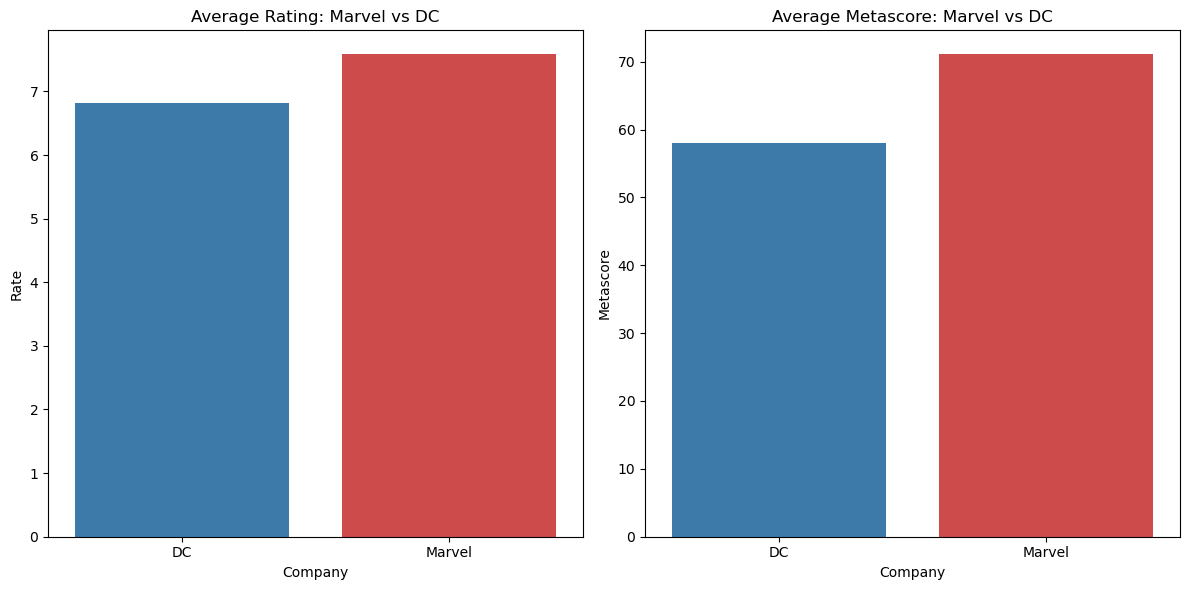

In [19]:
#Visualization of Average Rating and Metascore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
color = ['#2B7BBB', '#e23636']
sns.barplot(x='Company', y='Rate', data=avg_rating, palette= color)
plt.title('Average Rating: Marvel vs DC')

plt.subplot(1, 2, 2)
sns.barplot(x='Company', y='Metascore', data=avg_metascore, palette = color)
plt.title('Average Metascore: Marvel vs DC')

plt.tight_layout()
plt.show()

In [20]:
#top_gross_usa = df.nlargest(10,'Gross USA')[['Original Title', 'Company', 'Gross USA']]

#view top 10 grossing movies world wide
top_gross_worldwide = df.nlargest(10, 'Gross Worldwide')[['Original Title', 'Company', 'Gross Worldwide']]

#print(top_gross_usa)
print(top_gross_worldwide)

                        Original Title Company  Gross Worldwide
21                   Avengers: Endgame  Marvel       2797800564
5                         The Avengers  Marvel       1518812988
10            Avengers: Age of Ultron   Marvel       1402805868
17                       Black Panther  Marvel       1346913161
12          Captain America: Civil War  Marvel       1153296293
36                             Aquaman      DC       1148161807
22           Spider-Man: Far from Home  Marvel       1131927996
30               The Dark Knight Rises      DC       1081041287
26                     The Dark Knight      DC       1004934033
32  Batman v Superman: Dawn of Justice      DC        873634919


In [21]:
#top 10 rated films across both companies worldwide
top_rating_worldwide = df.nlargest(10, 'Rate')[['Original Title', 'Company', 'Rate']]

print(top_rating_worldwide)

                         Original Title Company  Rate
26                      The Dark Knight      DC   9.0
21                    Avengers: Endgame  Marvel   8.5
30                The Dark Knight Rises      DC   8.4
24                        Batman Begins      DC   8.2
5                          The Avengers  Marvel   8.0
9               Guardians of the Galaxy  Marvel   8.0
0                              Iron Man  Marvel   7.9
16                        Thor:Ragnarok  Marvel   7.9
12           Captain America: Civil War  Marvel   7.8
8   Captain America: The Winter Soldier  Marvel   7.7


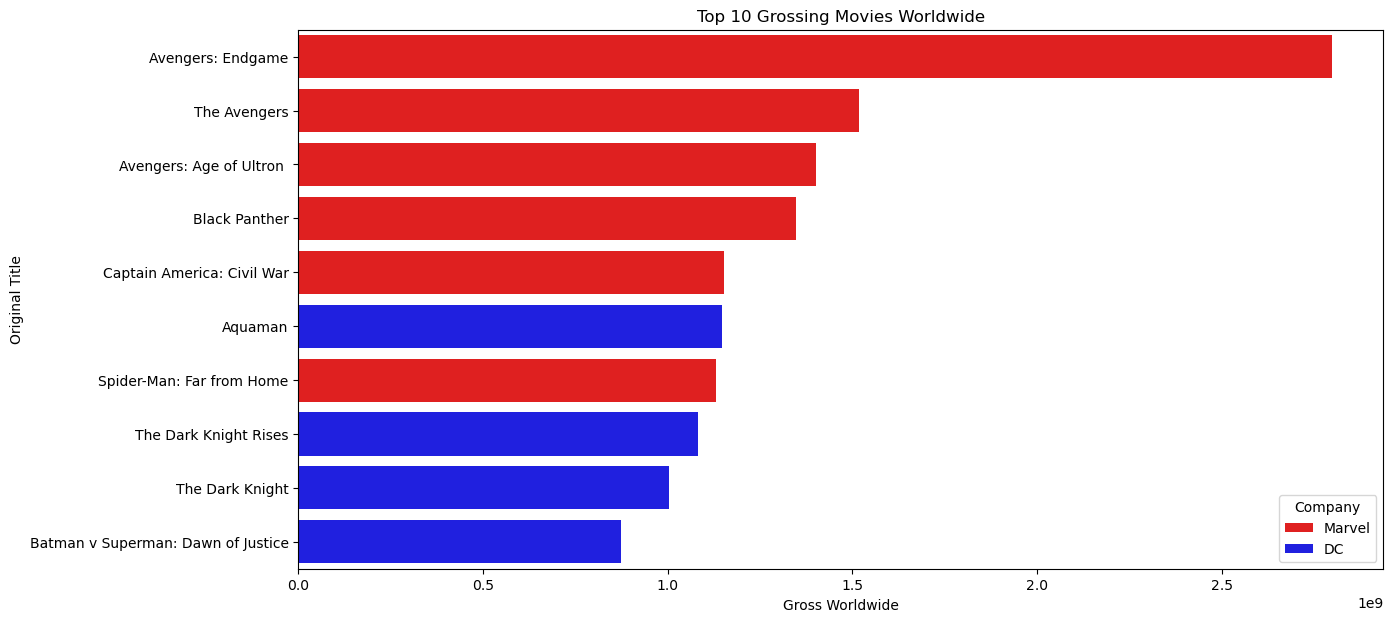

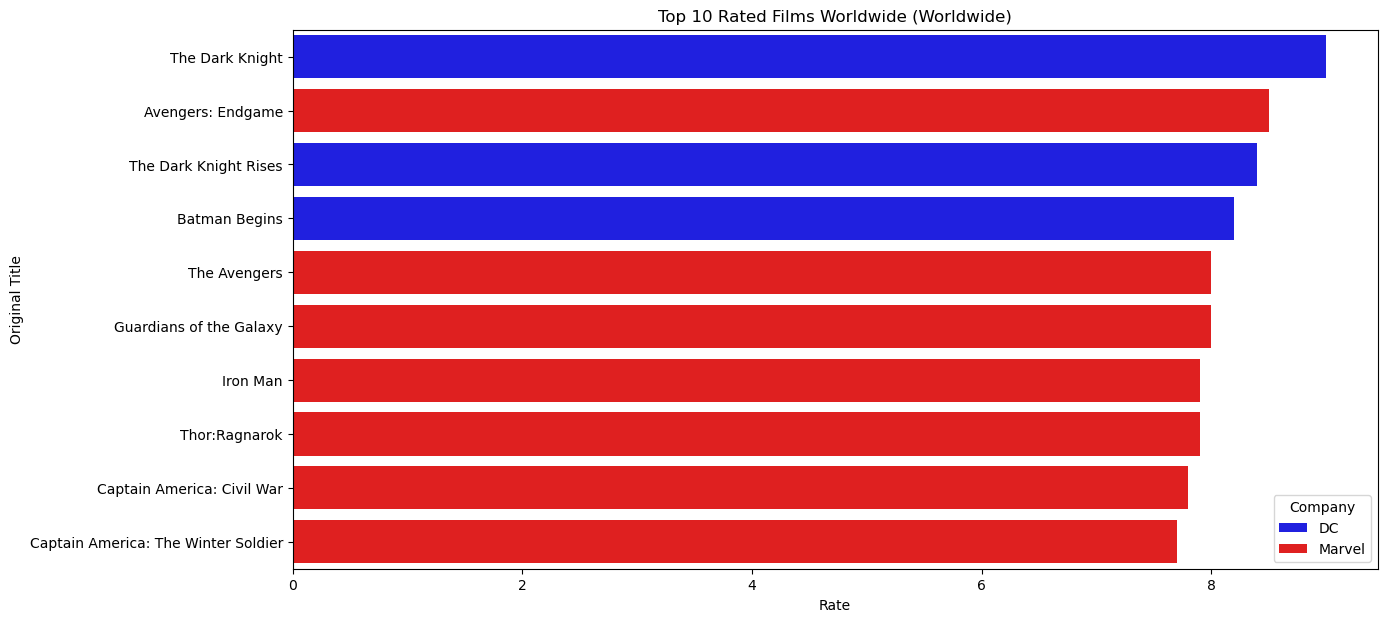

In [22]:
#Visualize top 10 gross films and top 10 rated movies

plt.figure(figsize=(14,7))
color = {'Marvel': 'red', 'DC': 'blue'}
sns.barplot(x='Gross Worldwide', y='Original Title', hue='Company', data= top_gross_worldwide, palette=color)
plt.title('Top 10 Grossing Movies Worldwide')
plt.show()

plt.figure(figsize=(14, 7))
sns.barplot(x='Rate', y ='Original Title', hue='Company', data=top_rating_worldwide, palette=color)
plt.title('Top 10 Rated Films Worldwide (Worldwide)')
plt.show()


In [23]:
#calculating return of investments which is gross - budget and add the column to the dataset

df['ROI'] = (df['Gross Worldwide'] - df['Budget']) / df['Budget']

budget_vs_roi = df.groupby('Company')['ROI'].mean().reset_index()
print(budget_vs_roi)

  Company       ROI
0      DC  2.307239
1  Marvel  3.948390


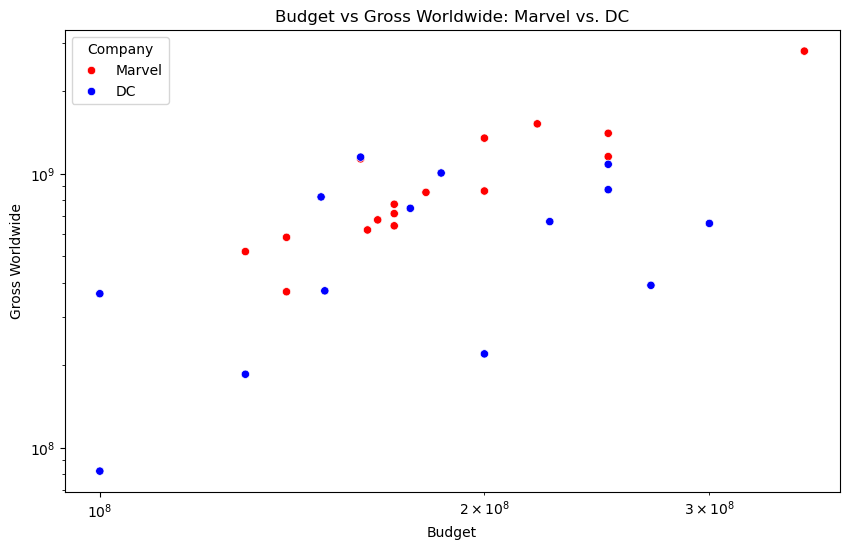

In [24]:
#visualization: Budget vs Gross Worldwide
plt.figure(figsize=(10, 6))
color = {'Marvel': 'red', 'DC': 'blue'}
sns.scatterplot(x= 'Budget', y='Gross Worldwide', hue='Company', data=df, palette=color)
plt.title('Budget vs Gross Worldwide: Marvel vs. DC')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [25]:
#compare runtime 
runtime = df.groupby('Company')['Minutes'].mean().reset_index
print(runtime)

<bound method Series.reset_index of Company
DC        138.785714
Marvel    131.875000
Name: Minutes, dtype: float64>


In [26]:
df['Performance'] = df['Rate'].apply(lambda x: 'High' if x >= 7.5 else 'low')
print(df.head())

                        Original Title Company  Rate  Metascore  Minutes  \
0                             Iron Man  Marvel   7.9         79    126.0   
4   Captain America: The First Avenger  Marvel   6.9         66    124.0   
5                         The Avengers  Marvel   8.0         69    143.0   
7                 Thor: The Dark World  Marvel   6.9         54    112.0   
8  Captain America: The Winter Soldier  Marvel   7.7         70    136.0   

   Release       Budget  Opening Weekend USA  Gross USA  Gross Worldwide  \
0     2008  140000000.0             98618668  318604126        585366247   
4     2011  140000000.0             65058524  176654505        370569774   
5     2012  220000000.0            207438708  623357910       1518812988   
7     2013  170000000.0             85737841  206362140        644783140   
8     2014  170000000.0             95023721  259766572        714421503   

                   Release Date       ROI Performance  
0 1970-01-01 00:00:00.00000200

In [27]:
df.head()

,Original Title,Company,Rate,Metascore,Minutes,Release,Budget,Opening Weekend USA,Gross USA,Gross Worldwide,Release Date,ROI,Performance
0,Iron Man,Marvel,7.9,79,126.0,2008,140000000.0,98618668,318604126,585366247,1970-01-01 00:00:00.000002008,3.181187,High
4,Captain America: The First Avenger,Marvel,6.9,66,124.0,2011,140000000.0,65058524,176654505,370569774,1970-01-01 00:00:00.000002011,1.646927,low
5,The Avengers,Marvel,8.0,69,143.0,2012,220000000.0,207438708,623357910,1518812988,1970-01-01 00:00:00.000002012,5.903695,High
7,Thor: The Dark World,Marvel,6.9,54,112.0,2013,170000000.0,85737841,206362140,644783140,1970-01-01 00:00:00.000002013,2.792842,low
8,Captain America: The Winter Soldier,Marvel,7.7,70,136.0,2014,170000000.0,95023721,259766572,714421503,1970-01-01 00:00:00.000002014,3.202479,High


In [28]:
for label, row in df.iterrows():
    if row['Performance'] == 'High':
        print(row['Original Title'])

Iron Man
The Avengers
Captain America: The Winter Soldier
Guardians of the Galaxy
Captain America: Civil War
Doctor Strange
Guardians of the Galaxy Vol. 2
Thor:Ragnarok
Avengers: Endgame
Spider-Man: Far from Home
Batman Begins
The Dark Knight
Watchmen
The Dark Knight Rises


In [29]:
print(df['Company'].unique()) # Get all unique companies

['Marvel' 'DC']


In [30]:
#Change marvel to value 1 and dc to value 0 in the company column
df['Company'] = df['Company'].map({
    'Marvel': 1,
    'DC':0}) #

In [31]:
#Random Forest Classifier


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
#select features and target col (target is binary usually)
features = ['Rate', 'Gross Worldwide', 'Metascore', 'Minutes']

X = df[features]
y = df['Performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         4
         low       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [64]:
df.columns

Index(['Original Title', 'Company', 'Rate', 'Metascore', 'Minutes', 'Release',
       'Budget', 'Opening Weekend USA', 'Gross USA', 'Gross Worldwide',
       'Release Date', 'ROI', 'Performance'],
      dtype='object')

In [70]:
from sklearn.linear_model import LogisticRegression

features = ['Rate', 'Gross Worldwide', 'Metascore', 'Minutes']

X = df[features]
y = df['Performance']

#split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#initialize and train model
model = LogisticRegression()
model.fit(X_train, y_train)

#predict on test set
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

Accuracy: 0.67
